In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# -----------------------------
# 1) device 설정 (GPU 있으면 cuda, 없으면 cpu)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
# -----------------------------
# 2) transform 설정
# - MNIST 이미지를 Tensor로 변환 (1, 28, 28)
# - ToTensor(): PIL/uint8 이미지의 픽셀값 0~255를 float 0~1로 변환
# - PIL: Python Imaging Library, uint8: 8-bit unsigned intege
# -----------------------------
transform = transforms.Compose([transforms.ToTensor()])
# -----------------------------
# 3) MNIST 데이터셋 다운로드/로드
# -----------------------------
train_dataset = datasets.MNIST( root="./data_gen", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST( root="./data_gen",  train=False,  download=True,  transform=transform)


device: cuda


In [2]:
print(type(train_dataset[0]))
img, label = train_dataset[0]
print(type(img))
print(img.dtype)
print(img.shape)
print(label)
print(img.min().item())

<class 'tuple'>
<class 'torch.Tensor'>
torch.float32
torch.Size([1, 28, 28])
5
0.0


In [3]:
# -----------------------------
# 4) DataLoader 설정
# - num_workers: 데이터를 병렬로 로딩하는 프로세스 개수, Jupyter/Windows면 0이 가장 안전
# - pin_memory: GPU 사용 시(CUDA) 전송 속도 개선에 도움, CPU만 쓰면 보통 False로 둠
# -----------------------------
num_workers = 0  # Jupyter/Windows에서는 0 권장 (에러/멈춤 방지)
pin = (device.type == "cuda")   # GPU일 때만 True
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin
)
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin
)
# -----------------------------
# 5) 확인: 배치 하나 꺼내서 shape + 값 범위 확인
# -----------------------------
x, y = next(iter(train_loader))
print("x shape:", x.shape)  # torch.Size([128, 1, 28, 28])
print("y shape:", y.shape)  # torch.Size([128])

print("x min/max:", x.min().item(), x.max().item())  #  0.0 ~ 1.0


x shape: torch.Size([128, 1, 28, 28])
y shape: torch.Size([128])
x min/max: 0.0 1.0


In [4]:
# 6) Encoder: 이미지(1x28x28)를 "잠재벡터(latent vector)"로 압축
class Encoder(nn.Module): # nn.Module 클래스 상속
    def __init__(self, encoded_space_dim): #생성자(초기화 함수)
        super().__init__() #부모 클래스 초기화

        #encoded_space_dim: 잠재벡터(z)의 차원(latent_dim)
        #fc2_input_dim: CNN 출력(Flatten) 길이 288

        # CNN으로 다운샘플링하며 특징 추출 (N,1,28,28) -> (N,32,3,3) 
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),   # (1,28,28) -> (8,14,14)
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),  # (8,14,14) -> (16,7,7)
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0), # (16,7,7) -> (32,3,3)
            nn.ReLU(True)
        )
        self.flatten = nn.Flatten(start_dim=1) # (N,32,3,3) -> (N, 32*3*3) = (N,288)

        # Flatten된 벡터를 중간 은닉층 거친 후 latent_dim으로 최종 압축
        # (N,288) -> (N,128) -> (N,latent_dim)
        self.encoder_lin = nn.Sequential(
            nn.Linear(288, 128), 
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)          # latent vector
        )
    def forward(self, x):
        x = self.encoder_cnn(x)   # (N,1,28,28) -> (N,32,3,3)
        x = self.flatten(x)       # (N,32,3,3) -> (N,288)
        x = self.encoder_lin(x)   # (N,288) -> (N,latent_dim)
        return x



In [5]:
# 7) Decoder: 잠재벡터(latent vector)를 다시 이미지로 복원(재구성)
class Decoder(nn.Module):
    def __init__(self, encoded_space_dim,):
        super().__init__()
        #encoded_space_dim: 잠재벡터(z)의 차원(latent_dim)
        # (N,latent_dim) -> (N,128) -> (N,288)
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True)
        )
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3)) # (N,288) -> (N,32,3,3)
        # ConvTranspose로 업샘플링하며 이미지 복원
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),         # (32,3,3) -> (16,7,7)
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),# (16,7,7) -> (8,14,14)
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)  # (8,14,14) -> (1,28,28)
        )
    def forward(self, x):
        x = self.decoder_lin(x)      # (N,latent_dim) -> (N,288)
        x = self.unflatten(x)        # (N,288) -> (N,32,3,3)
        x = self.decoder_conv(x)     # (N,32,3,3) -> (N,1,28,28)
        x = torch.sigmoid(x)  # 출력값을 0~1 범위로 (이미지 픽셀 값)
        return x

In [6]:
# 8) 모델 인스턴스화 및 최적화 설정
# 인코더/디코더 생성 (latent 차원=4)
encoder = Encoder(encoded_space_dim=4)
decoder = Decoder(encoded_space_dim=4)

# 모델을 GPU(cuda) 또는 CPU로 이동
encoder = encoder.to(device)
decoder = decoder.to(device)

# 인코더 + 디코더 파라미터를 함께 최적화하도록 설정
params_to_optimize = [
    {"params": encoder.parameters()},
    {"params": decoder.parameters()},
]

# Adam 옵티마이저 (lr: 학습률, weight_decay: L2 정규화)
optim = torch.optim.Adam(params_to_optimize, lr=0.001, weight_decay=1e-5)

# 오토인코더는 입력을 복원하므로 보통 MSELoss(재구성 오차)를 사용
loss_fn = torch.nn.MSELoss()


In [7]:
# 9) 데이터 전처리: 노이즈 추가 함수
def add_noise(inputs, noise_factor=0.3):
    # 입력 이미지에 가우시안 노이즈 추가
    noisy = inputs + torch.randn_like(inputs) * noise_factor
    # 픽셀 값이 0~1 범위를 벗어나지 않도록 자르기(clipping)
    noisy = torch.clip(noisy, 0.0, 1.0)
    return noisy


In [8]:
# 10) 모델 학습 루프
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer, noise_factor=0.3):
    # 학습 모드로 전환 (가중치 업데이트 가능 상태)
    encoder.train()
    decoder.train()
    
    train_loss = []
    # 배치 단위로 이미지 가져오기 (라벨은 사용하지 않음)
    for image_batch, _ in dataloader:
        # 입력 이미지에 노이즈를 추가 (denoising autoencoder)
        image_noisy = add_noise(image_batch, noise_factor)

        # 원본/노이즈 이미지를 device로 이동
        image_batch = image_batch.to(device)
        image_noisy = image_noisy.to(device)
        
        # 인코더로 압축 -> 디코더로 복원
        encoded = encoder(image_noisy)
        decoded = decoder(encoded)
        
        # 복원된 이미지(decoded)가 "원본 이미지(image_batch)"와 비슷해지도록 학습
        loss = loss_fn(decoded, image_batch)
        
        # 기울기 초기화 -> 역전파 -> 파라미터 업데이트
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # loss 값을 저장(평균 계산용)
        train_loss.append(loss.detach().cpu().item())
        
        # 한 epoch 동안의 평균 loss 반환
    return float(np.mean(train_loss))



In [9]:
# 11) 모델 평가 함수: 검증 데이터셋을 통해 모델의 일반화 성능을 측정
def test_epoch(encoder, decoder, device, dataloader, loss_fn, noise_factor=0.3):
    # 평가 모드로 전환 (Dropout/BatchNorm 등이 평가 방식으로 동작)
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():  # 평가에서는 gradient 계산 안 함(메모리/속도 절약)
        outputs = []
        targets = []
        
        for image_batch, _ in dataloader:
            # 입력 이미지를 device로 이동
            image_batch = image_batch.to(device)
            
            # denoising 평가를 원하면 노이즈 추가해서 입력으로 사용
            image_in = add_noise(image_batch, noise_factor).to(device)
            encoded = encoder(image_in)
            decoded = decoder(encoded)
            
            # CPU로 옮겨 리스트에 저장(전체 loss 계산용)
            outputs.append(decoded.cpu())
            targets.append(image_batch.cpu())
            
        # 배치들을 하나로 합치기
        outputs = torch.cat(outputs, dim=0)
        targets = torch.cat(targets, dim=0)
        
        # 전체 데이터에 대한 재구성 오차(loss) 계산
        val_loss = loss_fn(outputs, targets)
        
    # loss 텐서 반환 (원하면 val_loss.item()으로 숫자만 반환 가능)
    return val_loss


In [10]:
# 12) 결과 시각화 함수
import matplotlib.pyplot as plt
 # 원본 / 노이즈 / 재구성 이미지를 한 화면에 비교해서 보여주는 함수 
def plot_ae_outputs(encoder, decoder, n=5, noise_factor=0.3):
    plt.figure(figsize=(10, 4.5))
    
    # 평가 모드로 전환(한 번만)
    encoder.eval()
    decoder.eval()
    
    for i in range(n):
        # -------- 원본 이미지 --------
        ax = plt.subplot(3, n, i + 1)
        img = test_dataset[i][0].unsqueeze(0)  # (1, 1, 28, 28) 배치 형태로 만들기
        plt.imshow(img.squeeze().cpu().numpy(), cmap="gist_gray")
        ax.axis("off")
        if i == n // 2:
            ax.set_title("원래 이미지")
        
        # -------- 노이즈 이미지 --------
        ax = plt.subplot(3, n, i + 1 + n)
        image_noisy = add_noise(img, noise_factor).to(device)  # 노이즈 추가 후 device로 이동
        plt.imshow(image_noisy.squeeze().cpu().numpy(), cmap="gist_gray")
        ax.axis("off")
        if i == n // 2:
            ax.set_title("노이즈 이미지")
            
        # -------- 재구성 이미지 --------
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        with torch.no_grad():  # 평가에서는 gradient 불필요
            rec_img = decoder(encoder(image_noisy))  # 인코더->디코더로 복원
        plt.imshow(rec_img.squeeze().cpu().numpy(), cmap="gist_gray")
        ax.axis("off")
        if i == n // 2:
            ax.set_title("재구성 이미지")
            
    plt.tight_layout()
    plt.show()


In [11]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Windows 한글 폰트(맑은 고딕) 설정
font_fname = "C:/Windows/Fonts/malgun.ttf"
font_family = font_manager.FontProperties(fname=font_fname).get_name()
plt.rcParams["font.family"] = font_family

# (선택) 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False



EPOCH 1/30	train loss 0.102	val loss 0.042


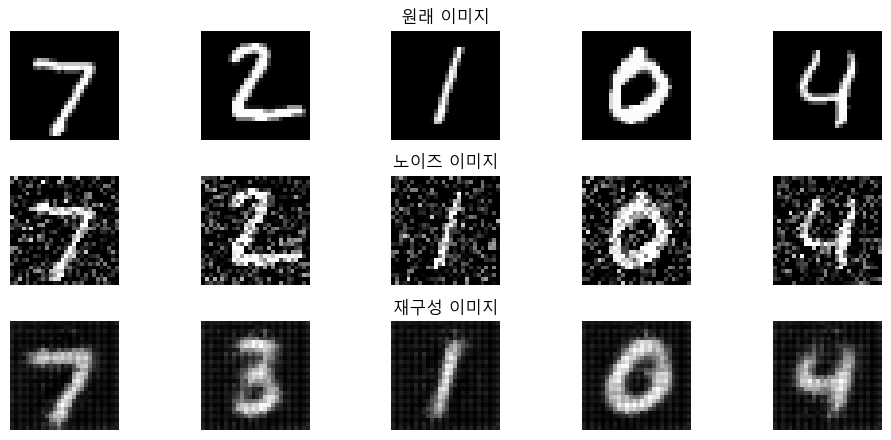


EPOCH 2/30	train loss 0.037	val loss 0.034


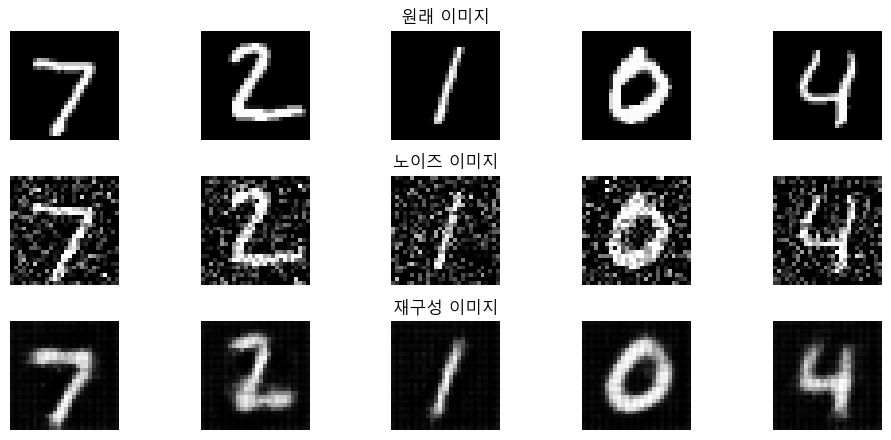


EPOCH 3/30	train loss 0.033	val loss 0.032


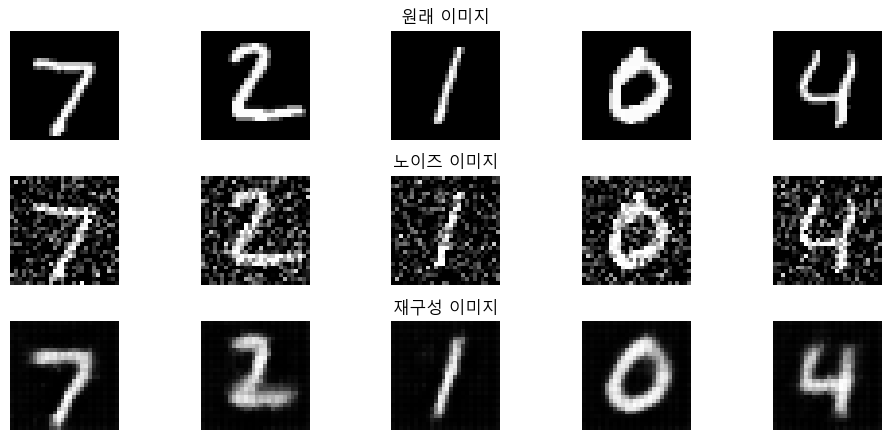


EPOCH 4/30	train loss 0.031	val loss 0.031


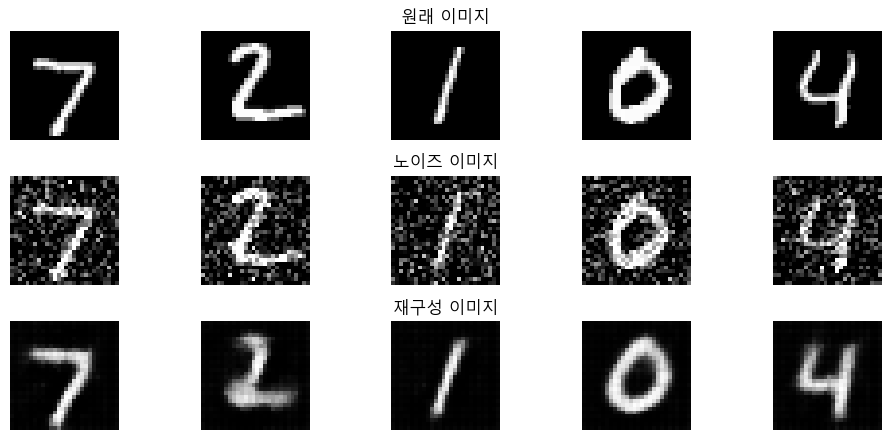


EPOCH 5/30	train loss 0.031	val loss 0.030


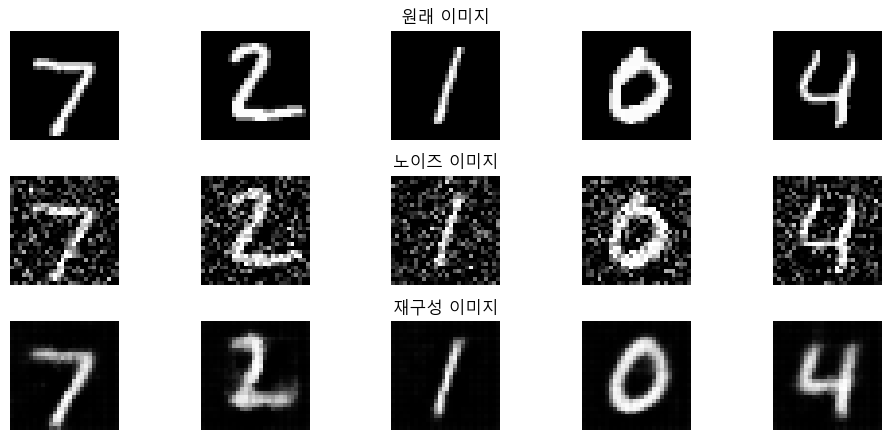


EPOCH 6/30	train loss 0.030	val loss 0.030


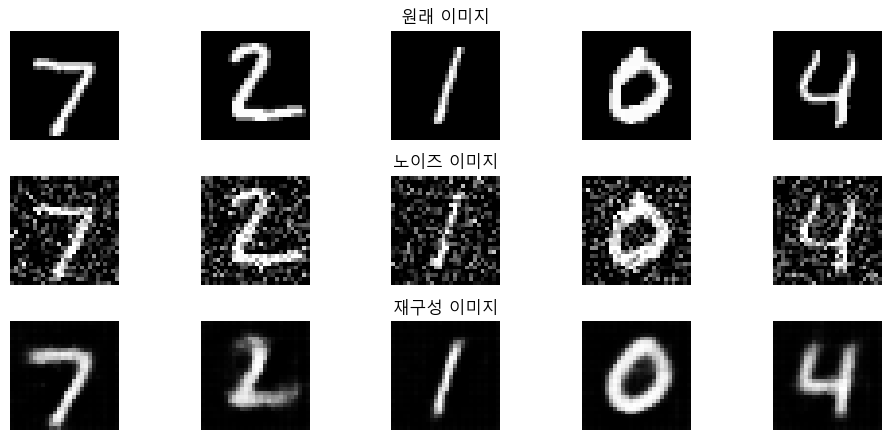


EPOCH 7/30	train loss 0.029	val loss 0.029


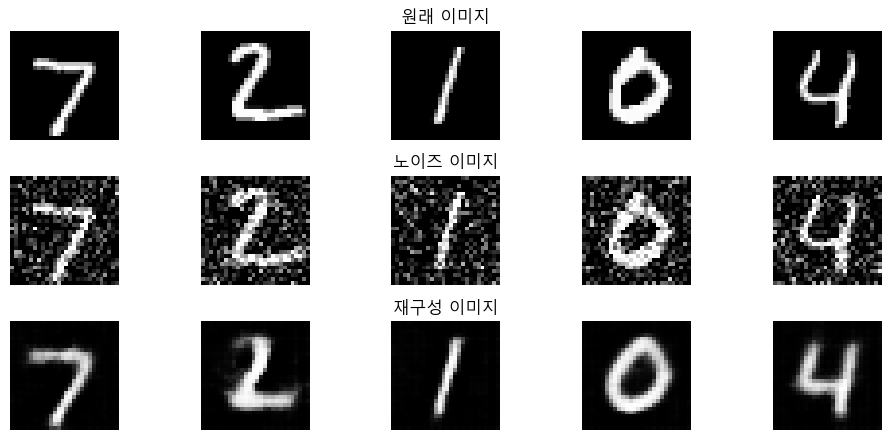


EPOCH 8/30	train loss 0.029	val loss 0.029


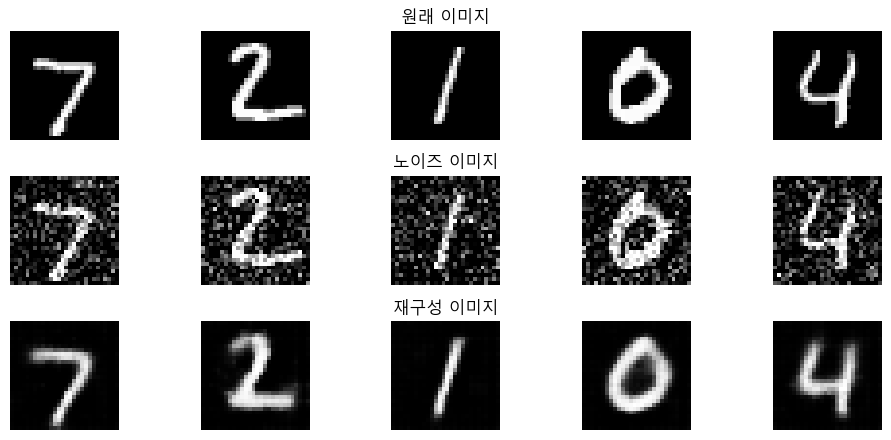


EPOCH 9/30	train loss 0.029	val loss 0.029


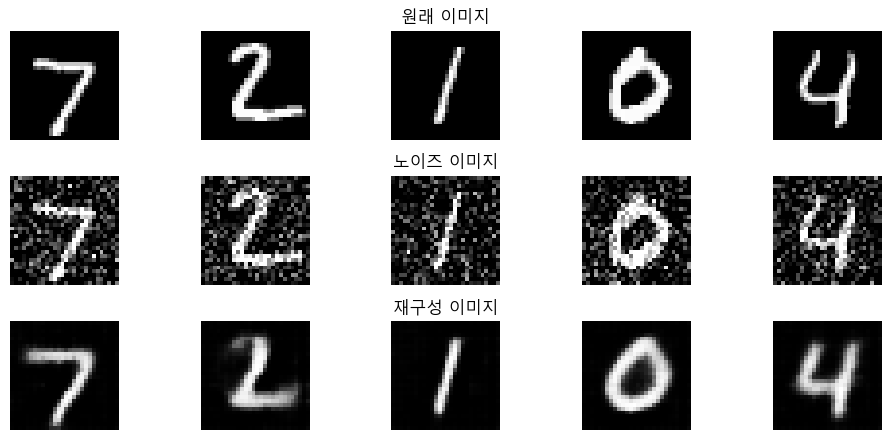


EPOCH 10/30	train loss 0.029	val loss 0.028


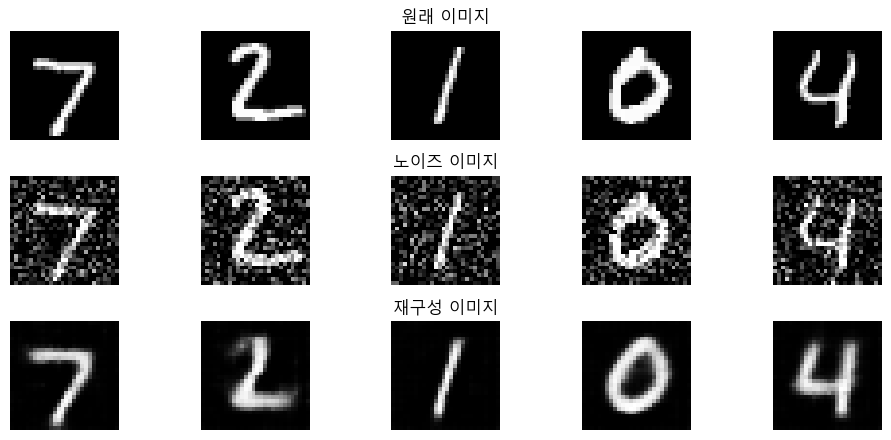


EPOCH 11/30	train loss 0.028	val loss 0.028


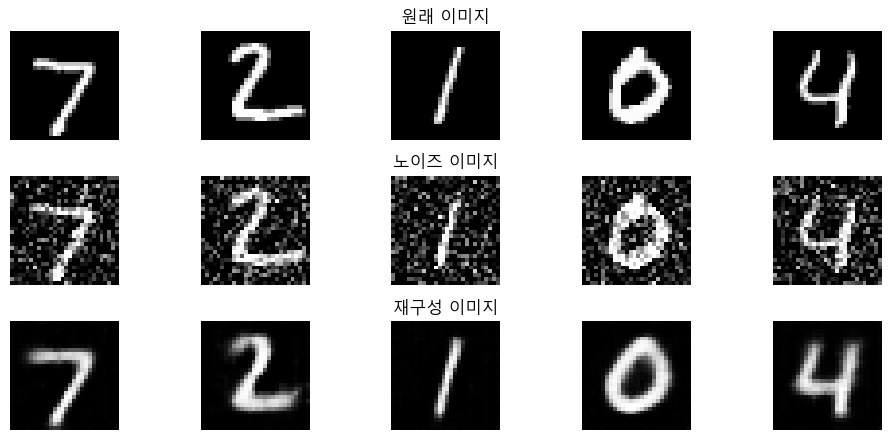


EPOCH 12/30	train loss 0.028	val loss 0.028


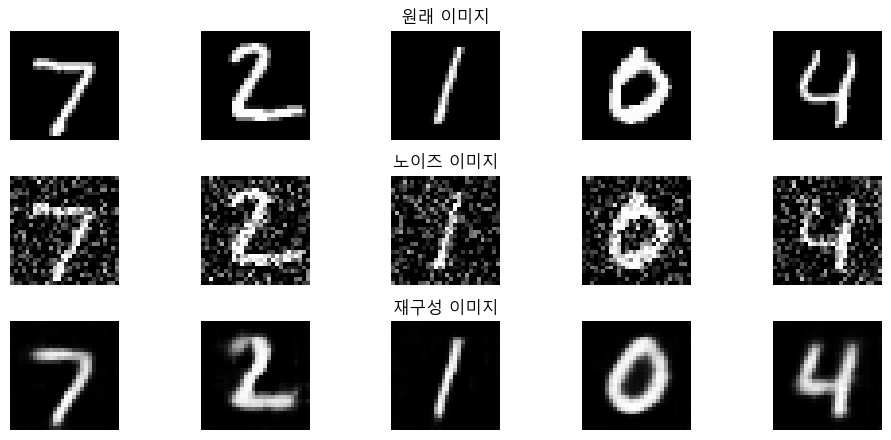


EPOCH 13/30	train loss 0.028	val loss 0.028


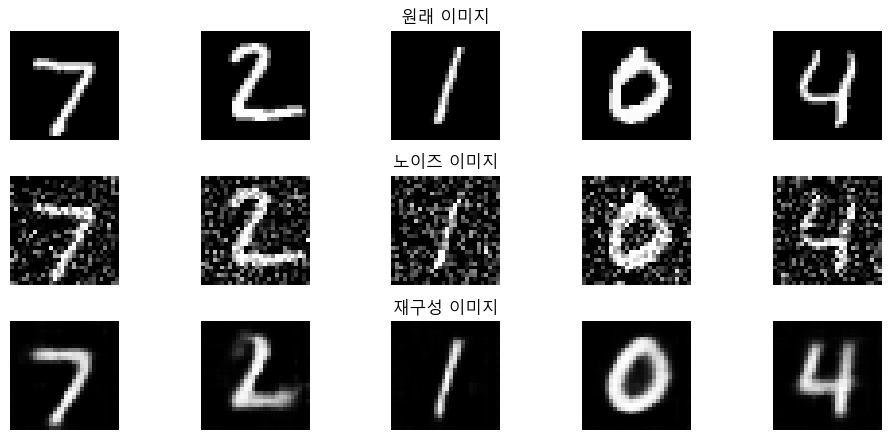


EPOCH 14/30	train loss 0.028	val loss 0.028


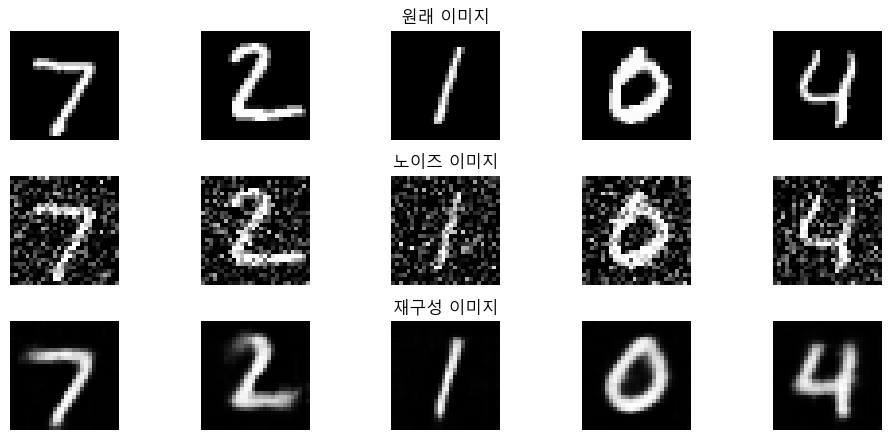


EPOCH 15/30	train loss 0.028	val loss 0.028


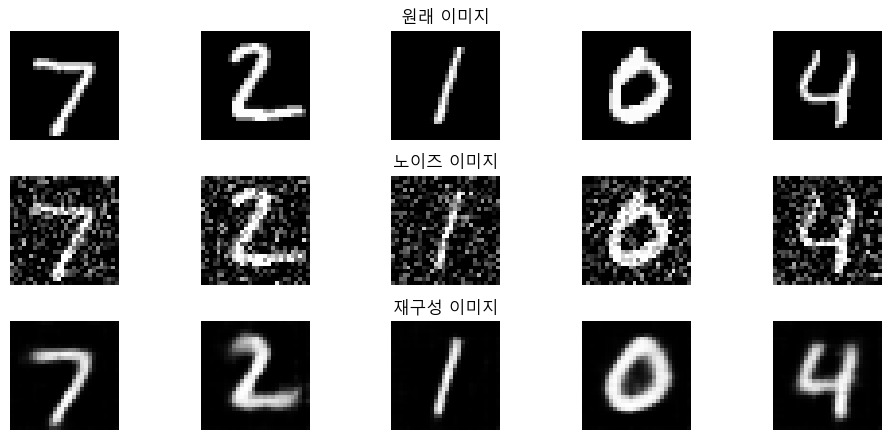


EPOCH 16/30	train loss 0.027	val loss 0.028


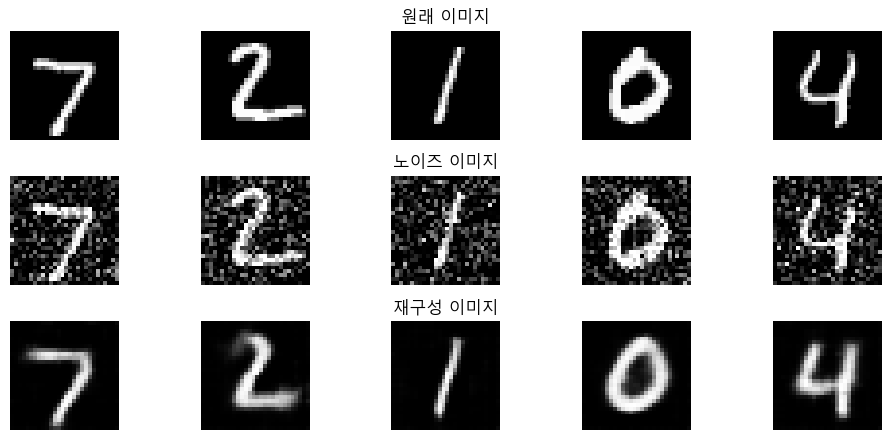


EPOCH 17/30	train loss 0.027	val loss 0.028


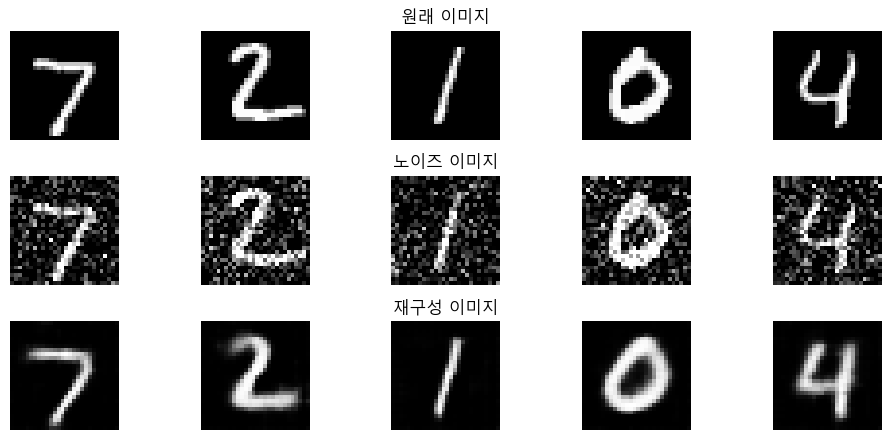


EPOCH 18/30	train loss 0.027	val loss 0.027


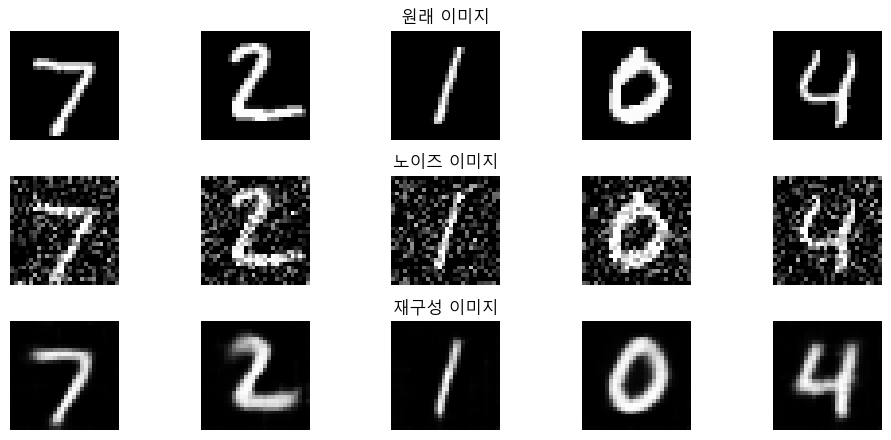


EPOCH 19/30	train loss 0.027	val loss 0.027


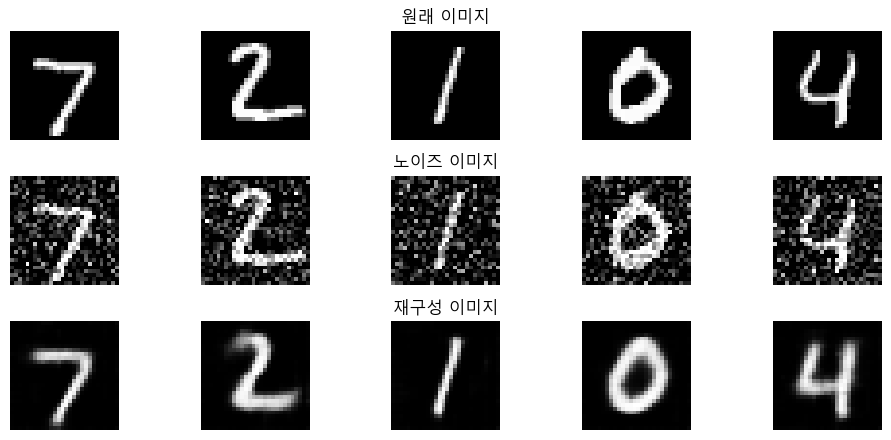


EPOCH 20/30	train loss 0.027	val loss 0.027


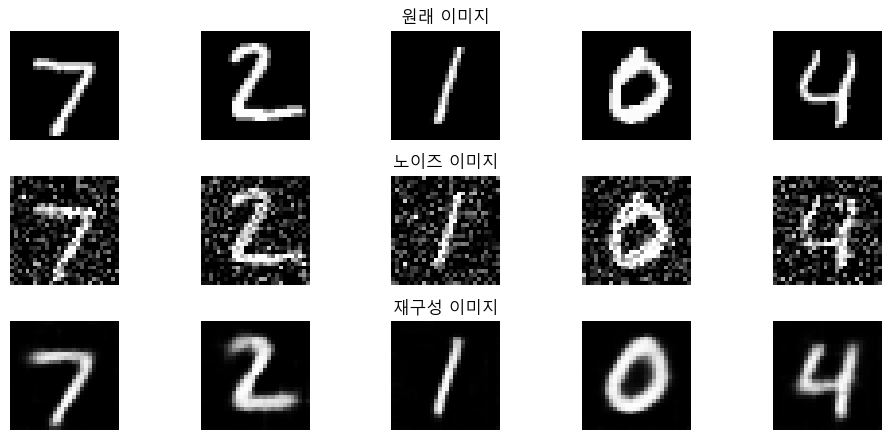


EPOCH 21/30	train loss 0.027	val loss 0.027


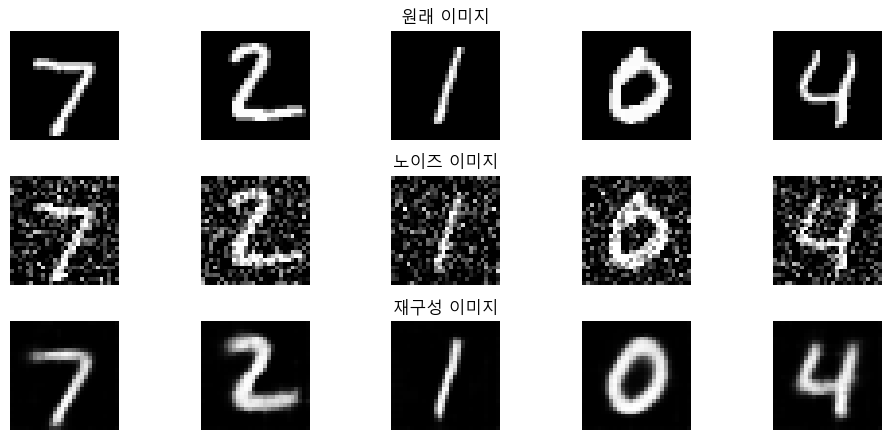


EPOCH 22/30	train loss 0.027	val loss 0.027


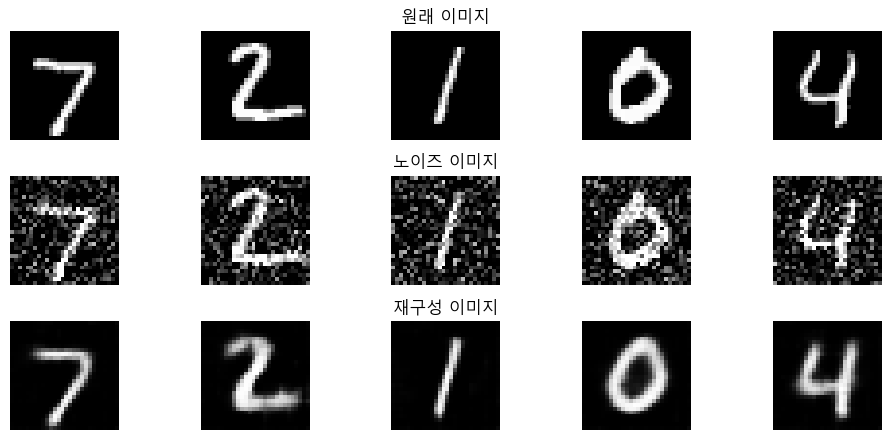


EPOCH 23/30	train loss 0.027	val loss 0.027


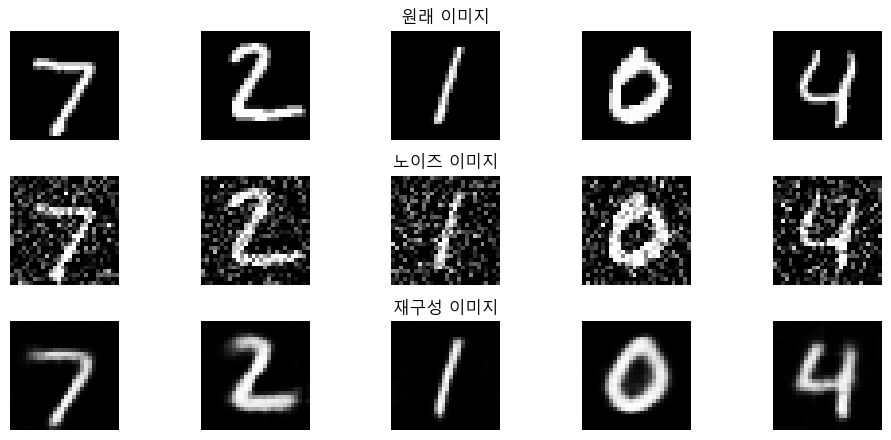


EPOCH 24/30	train loss 0.027	val loss 0.027


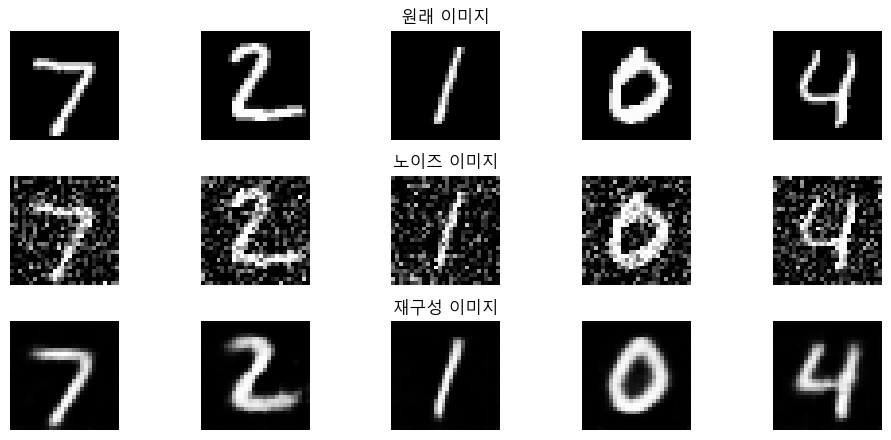


EPOCH 25/30	train loss 0.027	val loss 0.027


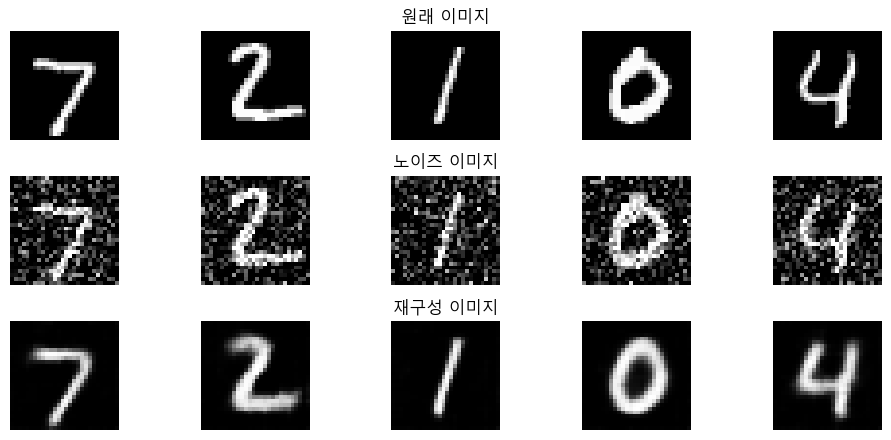


EPOCH 26/30	train loss 0.027	val loss 0.027


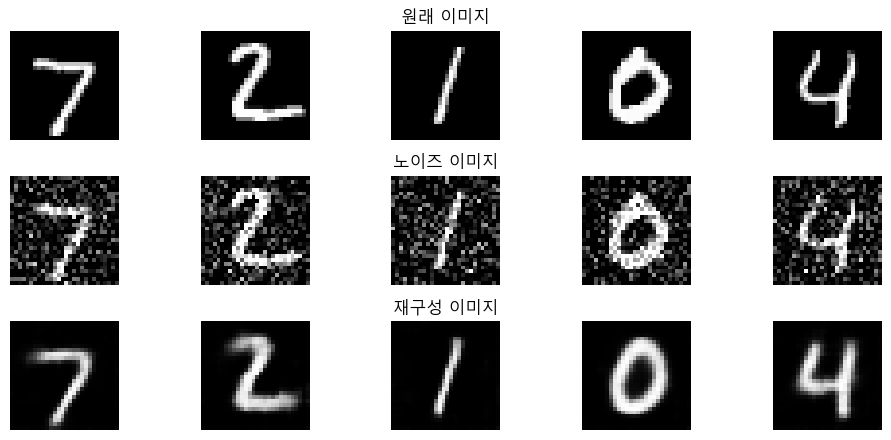


EPOCH 27/30	train loss 0.026	val loss 0.026


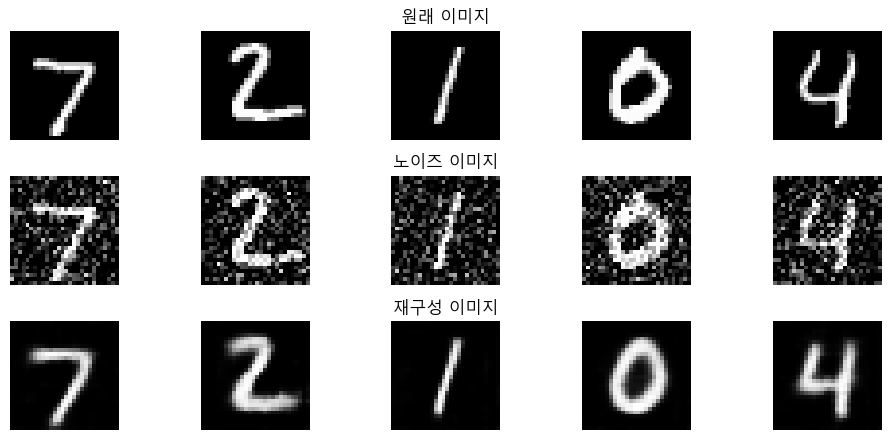


EPOCH 28/30	train loss 0.026	val loss 0.027


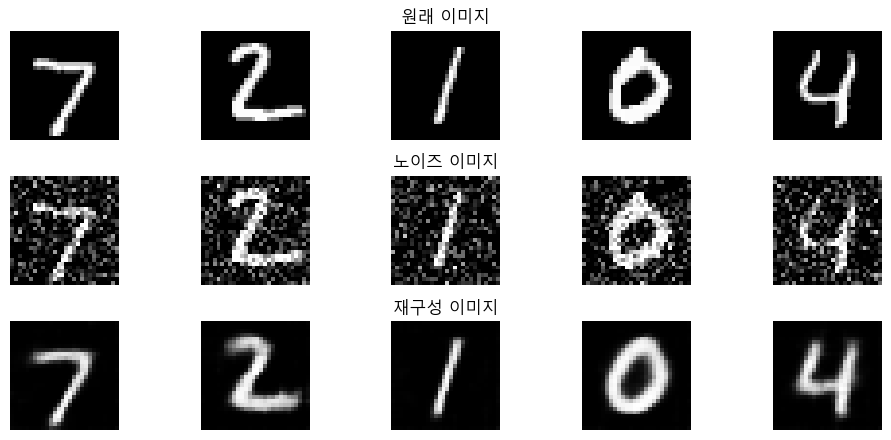


EPOCH 29/30	train loss 0.026	val loss 0.027


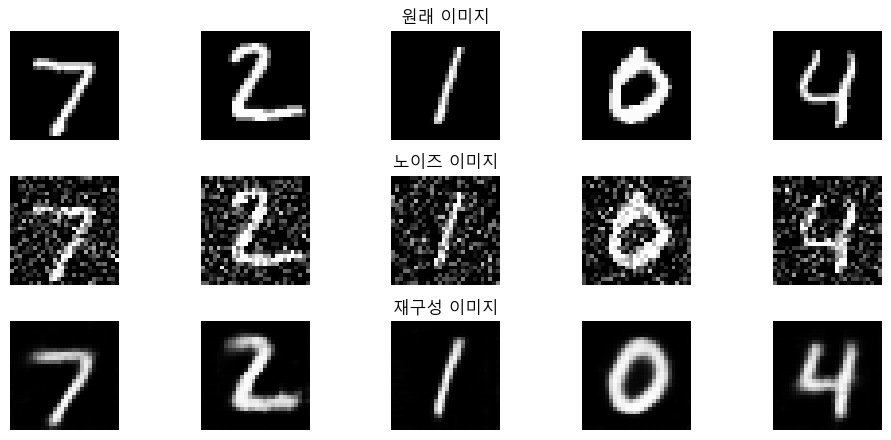


EPOCH 30/30	train loss 0.026	val loss 0.026


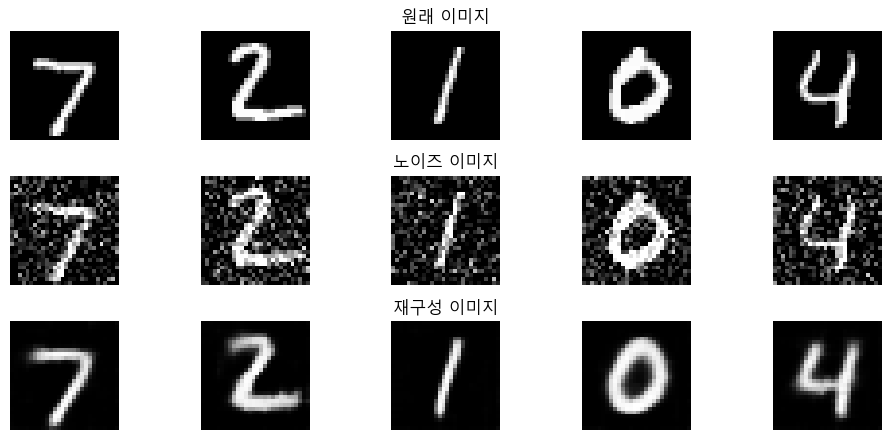

In [12]:
# 13) 전체 학습 실행 및 결과 기록
num_epochs = 30
history_da = {"train_loss": [], "val_loss": []} # 학습/검증 loss 기록용

loss_fn = torch.nn.MSELoss() # 오토인코더는 보통 재구성 오차(MSE)를 사용

for epoch in range(num_epochs):

    # 한 epoch 학습 (노이즈 입력 -> 원본 복원)
    train_loss = train_epoch(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optim,
        noise_factor=0.3
    )

    # 한 epoch 평가(검증) (복원 성능 측정)
    val_loss = test_epoch(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=test_loader,
        loss_fn=loss_fn,
        noise_factor=0.3
    )

    # 기록 저장 (val_loss가 텐서면 숫자로 변환)
    history_da["train_loss"].append(train_loss)
    history_da["val_loss"].append(val_loss.item() if torch.is_tensor(val_loss) else float(val_loss))

    # 로그 출력
    print(
        f"\nEPOCH {epoch+1}/{num_epochs}\t"
        f"train loss {train_loss:.3f}\t"
        f"val loss {history_da['val_loss'][-1]:.3f}"
    )

    # 원본/노이즈/재구성 이미지 시각화
    plot_ae_outputs(encoder, decoder, noise_factor=0.3)
